<center><h1>Vora_Raj_HW2</h1></center>
<br>
<br>

Name: Raj Vora
<br>
Github Username: RajVora622
<br>
USC ID: 9094527849

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

Get the Cycle Power Plant Data Set

In [2]:
data_path = "CCPP/Folds5x2_pp.xlsx"
data = pd.read_excel(data_path, sheet_name="Sheet1")
predictors = ["AT", "V", "AP", "RH"]
response = "PE"

display(data.head())
print(f"Shape: {data.shape}")
print(f"Missing values: {data.isna().sum().sum()}")

,AT,V,AP,RH,PE
0,14.9600,41.7600,1024.0700,73.1700,463.2600
1,25.1800,62.9600,1020.0400,59.0800,444.3700
2,5.1100,39.4000,1012.1600,92.1400,488.5600
3,20.8600,57.3200,1010.2400,76.6400,446.4800
4,10.8200,37.5000,1009.2300,96.6200,473.9000


Shape: (9568, 5)
Missing values: 0


`AT` is temperature, `V` is exhaust vacuum, `AP` is pressure, `RH` is humidity, and `PE` is the power output.

### (b) Exploring the data

#### i. rows and columns

In [3]:
dimension_summary = pd.DataFrame({
    "quantity": ["rows", "columns", "predictors", "response variables"],
    "count": [data.shape[0], data.shape[1], len(predictors), 1],
})
display(dimension_summary)

,quantity,count
0,rows,9568
1,columns,5
2,predictors,4
3,response variables,1


The data has **9,568 rows and 5 columns**. Each row is one hourly reading from the power plant. The first four columns are the predictors. `PE` is the response that we want to predict.

#### ii. pairwise scatterplots of all the variables

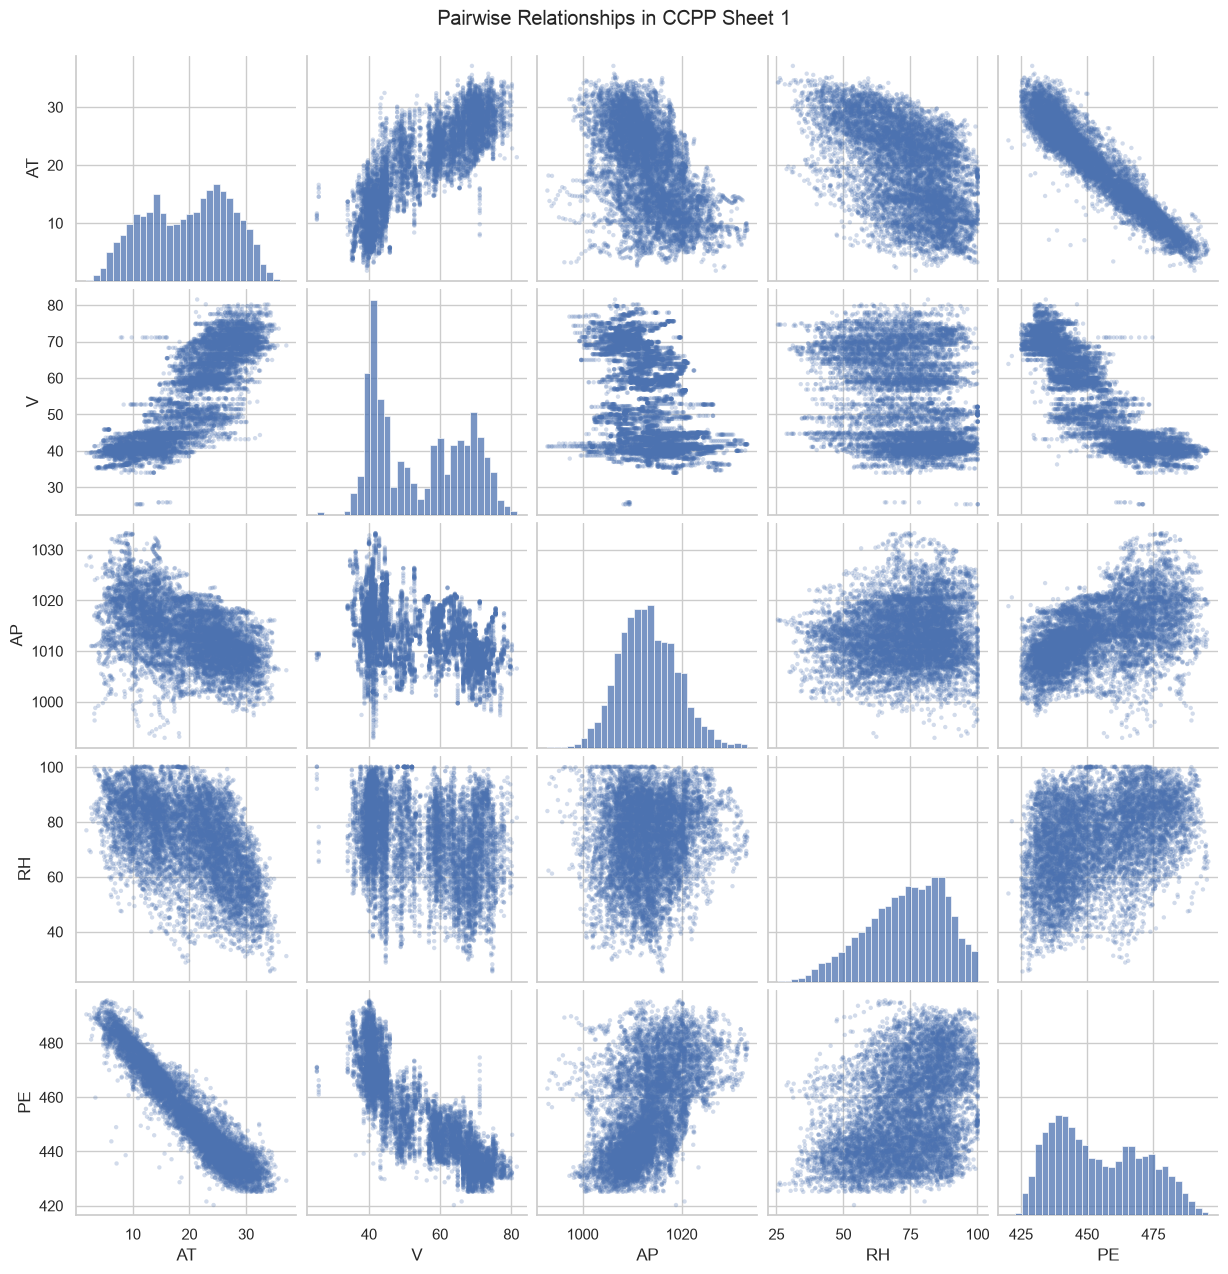

,AT,V,AP,RH,PE
AT,1.0000,0.8441,-0.5075,-0.5425,-0.9481
V,0.8441,1.0000,-0.4135,-0.3122,-0.8698
AP,-0.5075,-0.4135,1.0000,0.0996,0.5184
RH,-0.5425,-0.3122,0.0996,1.0000,0.3898
PE,-0.9481,-0.8698,0.5184,0.3898,1.0000


In [4]:
pairplot = sns.pairplot(
    data,
    diag_kind="hist",
    plot_kws={"alpha": 0.25, "s": 10, "edgecolor": "none"},
    diag_kws={"bins": 30},
)
pairplot.fig.suptitle("Pairwise Relationships in CCPP Sheet 1", y=1.02)
plt.show()

display(data.corr().round(4))

`PE` has a strong negative relationship with `AT` and `V`. This means that power output usually falls when temperature or exhaust vacuum rises. `PE` has a positive but weaker relationship with `AP` and `RH`. Also, `AT` and `V` are strongly related to each other. Some plots are curved, so a straight-line model may not capture every pattern.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
descriptive_statistics = pd.DataFrame({
    "mean": data.mean(),
    "median": data.median(),
    "minimum": data.min(),
    "maximum": data.max(),
    "range": data.max() - data.min(),
    "first quartile": data.quantile(0.25),
    "third quartile": data.quantile(0.75),
    "IQR": data.quantile(0.75) - data.quantile(0.25),
})
display(descriptive_statistics.round(3))

,mean,median,minimum,maximum,range,first quartile,third quartile,IQR
AT,19.6510,20.3450,1.8100,37.1100,35.3000,13.5100,25.7200,12.2100
V,54.3060,52.0800,25.3600,81.5600,56.2000,41.7400,66.5400,24.8000
AP,1013.2590,1012.9400,992.8900,1033.3000,40.4100,1009.1000,1017.2600,8.1600
RH,73.3090,74.9750,25.5600,100.1600,74.6000,63.3280,84.8300,21.5020
PE,454.3650,451.5500,420.2600,495.7600,75.5000,439.7500,468.4300,28.6800


The table gives the requested mean, median, range, first quartile, third quartile, and IQR for every variable.

### (c) Simple Linear Regression

,intercept,coefficient,p-value,R-squared,|studentized residual| > 3
predictor,,,,,
AT,497.0341,-2.1713,0.0000,0.8989,42
V,517.8015,-1.1681,0.0000,0.7565,33
AP,-1055.2610,1.4899,0.0000,0.2688,29
RH,420.9618,0.4557,0.0000,0.1519,2


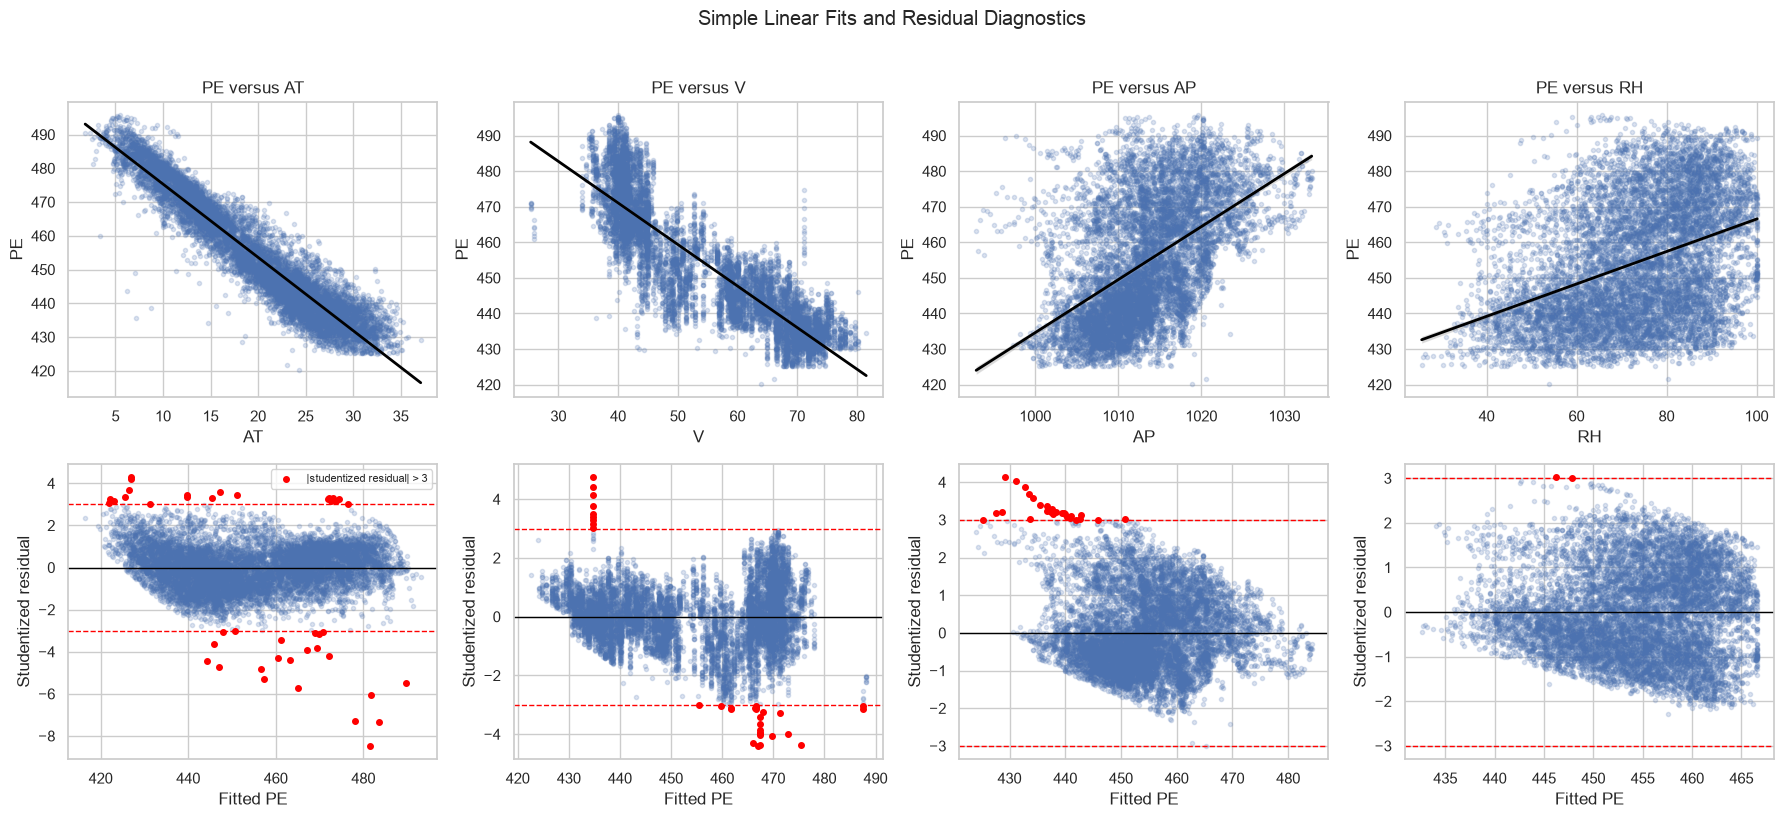

In [6]:
simple_models = {}
simple_records = []

for predictor in predictors:
    model = sm.OLS(data[response], sm.add_constant(data[[predictor]])).fit()
    simple_models[predictor] = model
    studentized = model.get_influence().resid_studentized_internal
    simple_records.append({
        "predictor": predictor,
        "intercept": model.params["const"],
        "coefficient": model.params[predictor],
        "p-value": model.pvalues[predictor],
        "R-squared": model.rsquared,
        "|studentized residual| > 3": int((np.abs(studentized) > 3).sum()),
    })

simple_summary = pd.DataFrame(simple_records).set_index("predictor")
display(simple_summary)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for column, predictor in enumerate(predictors):
    model = simple_models[predictor]
    fitted = model.fittedvalues
    studentized = model.get_influence().resid_studentized_internal
    potential_outlier = np.abs(studentized) > 3

    sns.regplot(
        data=data, x=predictor, y=response,
        scatter_kws={"alpha": 0.20, "s": 9},
        line_kws={"color": "black", "linewidth": 2},
        ax=axes[0, column],
    )
    axes[0, column].set_title(f"PE versus {predictor}")

    axes[1, column].scatter(fitted, studentized, alpha=0.20, s=9)
    axes[1, column].scatter(
        fitted[potential_outlier], studentized[potential_outlier],
        color="red", s=16, label="|studentized residual| > 3",
    )
    axes[1, column].axhline(0, color="black", linewidth=1)
    axes[1, column].axhline(3, color="red", linestyle="--", linewidth=1)
    axes[1, column].axhline(-3, color="red", linestyle="--", linewidth=1)
    axes[1, column].set(xlabel="Fitted PE", ylabel="Studentized residual")

axes[1, 0].legend(fontsize=8)
fig.suptitle("Simple Linear Fits and Residual Diagnostics", y=1.02)
fig.tight_layout()
plt.show()

All four predictors have p-values below 0.05, so each one has a significant relationship with `PE` when used alone. `AT` is the best single predictor because it has the largest $R^2$ value, 0.8989. `V` is next with an $R^2$ of 0.7565.

The residual check marks 42 points for `AT`, 33 for `V`, 29 for `AP`, and 2 for `RH` as possible outliers. I would check these points, but I would not remove them without proof that they are errors. Some large residuals may come from the curved patterns in the data.

### (d) Multiple Regression

In [7]:
multiple_model = sm.OLS(
    data[response], sm.add_constant(data[predictors])
).fit()

multiple_summary = pd.DataFrame({
    "coefficient": multiple_model.params,
    "standard error": multiple_model.bse,
    "t statistic": multiple_model.tvalues,
    "p-value": multiple_model.pvalues,
})
display(multiple_summary)
print(f"R-squared: {multiple_model.rsquared:.4f}")
print(f"Adjusted R-squared: {multiple_model.rsquared_adj:.4f}")

,coefficient,standard error,t statistic,p-value
const,454.6093,9.7485,46.6337,0.0000
AT,-1.9775,0.0153,-129.3420,0.0000
V,-0.2339,0.0073,-32.1221,0.0000
AP,0.0621,0.0095,6.5641,0.0000
RH,-0.1581,0.0042,-37.9185,0.0000


R-squared: 0.9287
Adjusted R-squared: 0.9287


The fitted model is

$$\widehat{PE}=454.6093-1.9775AT-0.2339V+0.0621AP-0.1581RH.$$

The model has an $R^2$ of 0.9287, so it explains about 92.9% of the change in `PE`. All four predictors have p-values below 0.05. Therefore, we reject $H_0:\beta_j=0$ for all four predictors.

### (e) 1c Compare to 1d

,simple coefficient,multiple coefficient
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


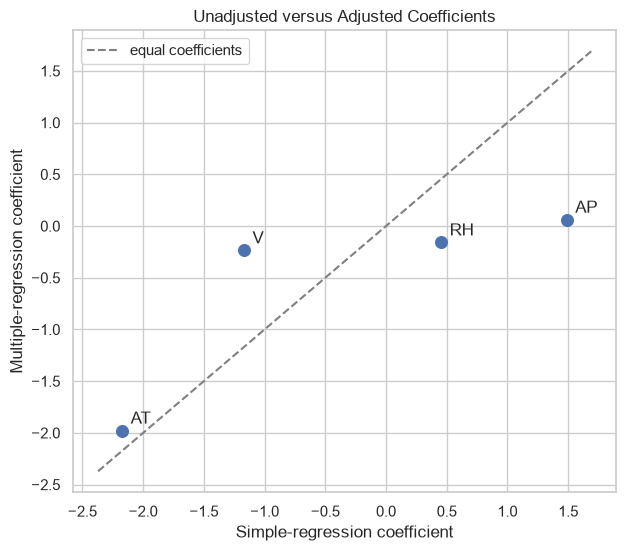

In [8]:
coefficient_comparison = pd.DataFrame({
    "simple coefficient": simple_summary["coefficient"],
    "multiple coefficient": multiple_model.params[predictors],
})
display(coefficient_comparison)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    coefficient_comparison["simple coefficient"],
    coefficient_comparison["multiple coefficient"],
    s=70,
)
for predictor, row in coefficient_comparison.iterrows():
    ax.annotate(
        predictor,
        (row["simple coefficient"], row["multiple coefficient"]),
        xytext=(6, 5), textcoords="offset points",
    )
limits = [
    min(coefficient_comparison.min()) - 0.2,
    max(coefficient_comparison.max()) + 0.2,
]
ax.plot(limits, limits, color="gray", linestyle="--", label="equal coefficients")
ax.set(
    xlabel="Simple-regression coefficient",
    ylabel="Multiple-regression coefficient",
    title="Unadjusted versus Adjusted Coefficients",
)
ax.legend()
plt.show()

The `AT` coefficient stays large and negative in both models. The `V` and `AP` coefficients become much smaller in the multiple model. The `RH` coefficient changes from positive to negative. This happens because the predictors are related to each other. A simple model does not adjust for the other predictors, but the multiple model does.

### (f) Nonlinear Association

,quadratic coefficient,quadratic p-value,cubic coefficient,cubic p-value,joint nonlinear F,joint nonlinear p-value,R-squared
predictor,,,,,,,
AT,0.0326,0.0000,0.0027,0.0000,701.9673,0.0000,0.9119
V,0.0192,0.0000,0.0001,0.0137,393.3141,0.0000,0.7750
AP,0.0442,0.0000,-0.0050,0.0000,195.8856,0.0000,0.2975
RH,-0.0013,0.1014,-0.0002,0.0000,10.1889,0.0000,0.1537


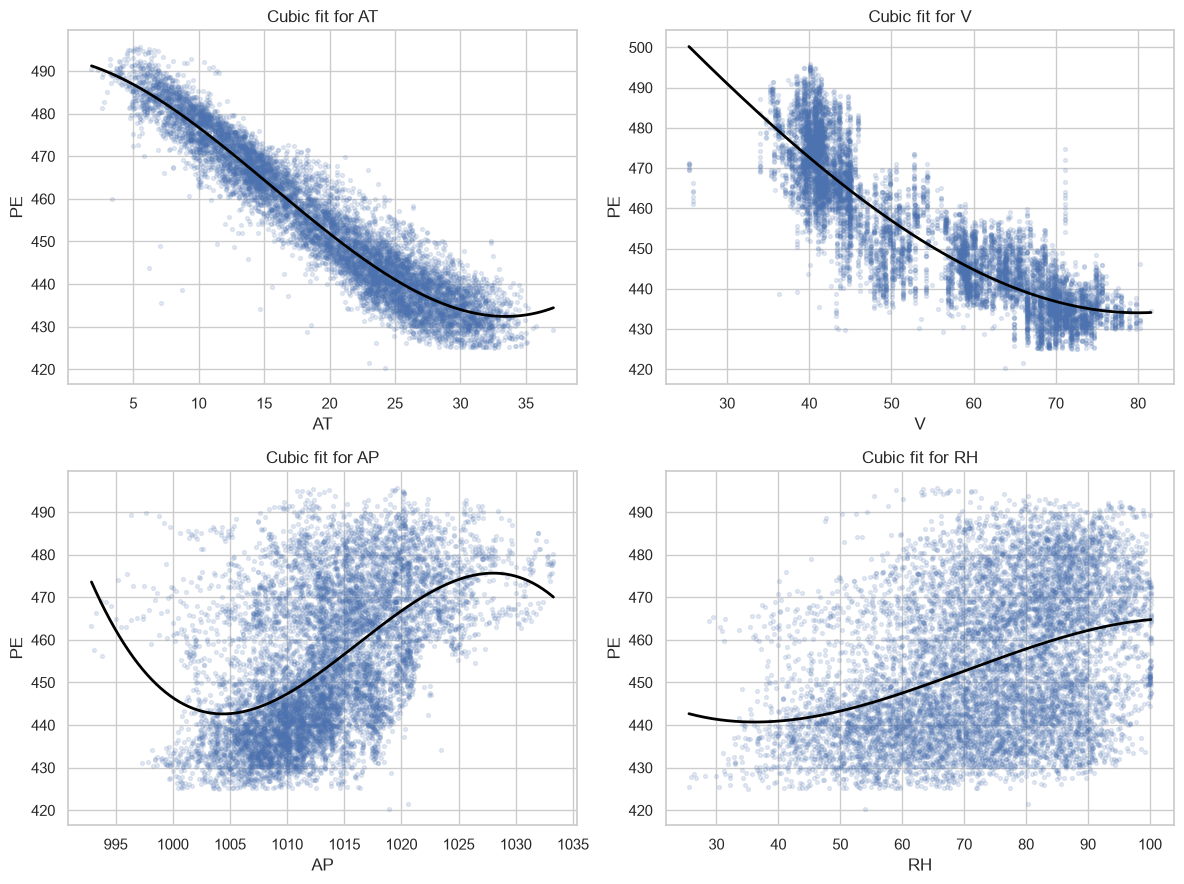

In [9]:
polynomial_records = []
polynomial_models = {}

for predictor in predictors:
    # Centering produces the same cubic model space while avoiding ill-conditioning,
    # particularly for AP, whose values are near 1,000.
    centered = data[predictor] - data[predictor].mean()
    design = pd.DataFrame({
        predictor: centered,
        f"{predictor}^2": centered ** 2,
        f"{predictor}^3": centered ** 3,
    })
    model = sm.OLS(data[response], sm.add_constant(design)).fit()
    polynomial_models[predictor] = model
    nonlinear_test = model.f_test(
        np.array([[0, 0, 1, 0], [0, 0, 0, 1]])
    )
    polynomial_records.append({
        "predictor": predictor,
        "quadratic coefficient": model.params[f"{predictor}^2"],
        "quadratic p-value": model.pvalues[f"{predictor}^2"],
        "cubic coefficient": model.params[f"{predictor}^3"],
        "cubic p-value": model.pvalues[f"{predictor}^3"],
        "joint nonlinear F": float(nonlinear_test.fvalue),
        "joint nonlinear p-value": float(nonlinear_test.pvalue),
        "R-squared": model.rsquared,
    })

polynomial_summary = pd.DataFrame(polynomial_records).set_index("predictor")
display(polynomial_summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, predictor in zip(axes.flat, predictors):
    grid = np.linspace(data[predictor].min(), data[predictor].max(), 300)
    centered_grid = grid - data[predictor].mean()
    grid_design = pd.DataFrame({
        predictor: centered_grid,
        f"{predictor}^2": centered_grid ** 2,
        f"{predictor}^3": centered_grid ** 3,
    })
    ax.scatter(data[predictor], data[response], alpha=0.15, s=8)
    ax.plot(grid, polynomial_models[predictor].predict(sm.add_constant(grid_design)),
            color="black", linewidth=2)
    ax.set(xlabel=predictor, ylabel=response, title=f"Cubic fit for {predictor}")
fig.tight_layout()
plt.show()

I center each predictor before making its square and cube. This makes the calculation more stable but gives the same possible cubic curves. For every predictor, the joint p-value for the square and cube is below 0.05. Therefore, `AT`, `V`, `AP`, and `RH` all show evidence of a nonlinear relationship with `PE`. The nonlinear effect for `RH` is the weakest.

### (g) Interactions of Predictors

In [10]:
centered_predictors = data[predictors] - data[predictors].mean()
interaction_transformer = PolynomialFeatures(
    degree=2, interaction_only=True, include_bias=False
)
interaction_design = pd.DataFrame(
    interaction_transformer.fit_transform(centered_predictors),
    columns=interaction_transformer.get_feature_names_out(predictors),
    index=data.index,
)
interaction_model = sm.OLS(
    data[response], sm.add_constant(interaction_design)
).fit()

interaction_summary = pd.DataFrame({
    "coefficient": interaction_model.params,
    "p-value": interaction_model.pvalues,
})
display(interaction_summary)

,coefficient,p-value
const,452.6946,0.0000
AT,-1.8092,0.0000
V,-0.2986,0.0000
AP,0.1340,0.0000
RH,-0.1195,0.0000
AT V,0.0210,0.0000
AT AP,0.0018,0.4521
AT RH,-0.0052,0.0000
V AP,0.0068,0.0000
V RH,0.0008,0.0862


Using $\alpha=0.05$, the significant interactions are `AT V`, `AT RH`, `V AP`, and `AP RH`. The `AT AP` and `V RH` interactions are not significant.

### (h) Improvement

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data[predictors], data[response], test_size=0.30, random_state=42
)

linear_train_design = sm.add_constant(X_train)
linear_test_design = sm.add_constant(X_test, has_constant="add")
linear_model = sm.OLS(y_train, linear_train_design).fit()

linear_train_mse = mean_squared_error(
    y_train, linear_model.predict(linear_train_design)
)
linear_test_mse = mean_squared_error(
    y_test, linear_model.predict(linear_test_design)
)

training_means = X_train.mean()
quadratic_transformer = PolynomialFeatures(degree=2, include_bias=False)
expanded_train = pd.DataFrame(
    quadratic_transformer.fit_transform(X_train - training_means),
    columns=quadratic_transformer.get_feature_names_out(predictors),
    index=X_train.index,
)
expanded_test = pd.DataFrame(
    quadratic_transformer.transform(X_test - training_means),
    columns=quadratic_transformer.get_feature_names_out(predictors),
    index=X_test.index,
)

selected_terms = list(expanded_train.columns)
removed_terms = []
while True:
    selected_model = sm.OLS(
        y_train, sm.add_constant(expanded_train[selected_terms])
    ).fit()
    removable_pvalues = selected_model.pvalues.drop("const").drop(
        labels=predictors, errors="ignore"
    )
    if removable_pvalues.max() <= 0.05:
        break
    term_to_remove = removable_pvalues.idxmax()
    removed_terms.append((term_to_remove, removable_pvalues[term_to_remove]))
    selected_terms.remove(term_to_remove)

selected_train_design = sm.add_constant(expanded_train[selected_terms])
selected_test_design = sm.add_constant(
    expanded_test[selected_terms], has_constant="add"
)
selected_train_mse = mean_squared_error(
    y_train, selected_model.predict(selected_train_design)
)
selected_test_mse = mean_squared_error(
    y_test, selected_model.predict(selected_test_design)
)

print("Removed second-order terms:")
display(pd.DataFrame(removed_terms, columns=["term", "p-value when removed"]))
print("Final selected terms:")
print(selected_terms)
display(pd.DataFrame({
    "coefficient": selected_model.params,
    "p-value": selected_model.pvalues,
}))

regression_mse_summary = pd.DataFrame([
    {"model": "All predictors, linear", "train MSE": linear_train_mse,
     "test MSE": linear_test_mse},
    {"model": "Selected quadratic + interactions", "train MSE": selected_train_mse,
     "test MSE": selected_test_mse},
]).set_index("model")
display(regression_mse_summary)

Removed second-order terms:


,term,p-value when removed
0,V RH,0.8674
1,V^2,0.6077
2,V AP,0.3578


Final selected terms:
['AT', 'V', 'AP', 'RH', 'AT^2', 'AT V', 'AT AP', 'AT RH', 'AP^2', 'AP RH', 'RH^2']


,coefficient,p-value
const,453.2275,0.0000
AT,-1.8173,0.0000
V,-0.2985,0.0000
AP,0.1169,0.0000
RH,-0.1251,0.0000
AT^2,0.0195,0.0000
AT V,0.0082,0.0000
AT AP,0.0070,0.0015
AT RH,-0.0055,0.0000
AP^2,-0.0076,0.0000


,train MSE,test MSE
model,,
"All predictors, linear",20.5808,21.2399
Selected quadratic + interactions,17.8908,18.6600


The basic linear model has a training MSE of 20.5808 and a test MSE of 21.2399. After removing the nonsignificant second-order terms `V RH`, `V^2`, and `V AP`, the improved model has a training MSE of 17.8908 and a test MSE of 18.6600. The improved model performs better because both errors are smaller.

### (i) KNN

,best k,train MSE at best k,test MSE at best k
features,,,
raw,5,10.6008,15.7268
normalized,4,8.5914,14.3057


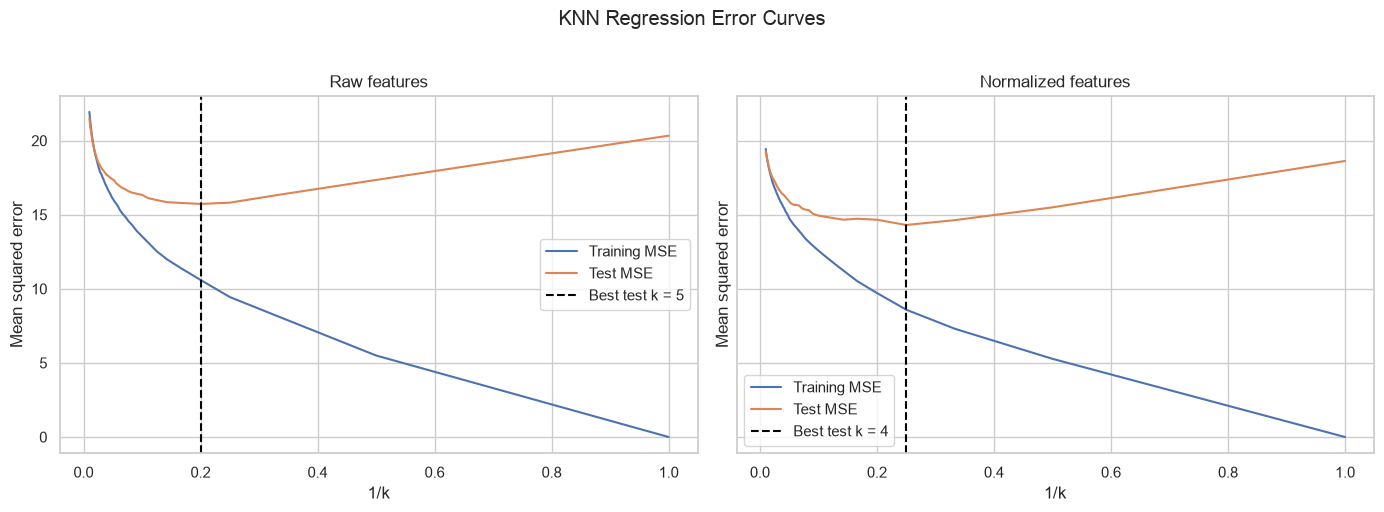

In [ ]:
def knn_error_curves(X_train_values, X_test_values, y_train_values, y_test_values,
                     max_k=100):
    neighbors = NearestNeighbors(n_neighbors=max_k)
    neighbors.fit(X_train_values)

    train_indices = neighbors.kneighbors(X_train_values, return_distance=False)
    test_indices = neighbors.kneighbors(X_test_values, return_distance=False)

    divisors = np.arange(1, max_k + 1)
    train_predictions = (
        np.cumsum(y_train_values[train_indices], axis=1) / divisors
    )
    test_predictions = (
        np.cumsum(y_train_values[test_indices], axis=1) / divisors
    )

    train_mse = np.mean(
        (train_predictions - y_train_values[:, None]) ** 2, axis=0
    )
    test_mse = np.mean(
        (test_predictions - y_test_values[:, None]) ** 2, axis=0
    )
    return train_mse, test_mse


raw_train = X_train.to_numpy()
raw_test = X_test.to_numpy()
y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

scaler = StandardScaler()
normalized_train = scaler.fit_transform(X_train)
normalized_test = scaler.transform(X_test)

raw_train_mse, raw_test_mse = knn_error_curves(
    raw_train, raw_test, y_train_array, y_test_array
)
normalized_train_mse, normalized_test_mse = knn_error_curves(
    normalized_train, normalized_test, y_train_array, y_test_array
)

k_values = np.arange(1, 101)
raw_best_k = int(np.argmin(raw_test_mse) + 1)
normalized_best_k = int(np.argmin(normalized_test_mse) + 1)

knn_summary = pd.DataFrame([
    {
        "features": "raw",
        "best k": raw_best_k,
        "train MSE at best k": raw_train_mse[raw_best_k - 1],
        "test MSE at best k": raw_test_mse[raw_best_k - 1],
    },
    {
        "features": "normalized",
        "best k": normalized_best_k,
        "train MSE at best k": normalized_train_mse[normalized_best_k - 1],
        "test MSE at best k": normalized_test_mse[normalized_best_k - 1],
    },
]).set_index("features")
display(knn_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
inverse_k = 1 / k_values

for ax, title, train_errors, test_errors, best_k in [
    (axes[0], "Raw features", raw_train_mse, raw_test_mse, raw_best_k),
    (axes[1], "Normalized features", normalized_train_mse,
     normalized_test_mse, normalized_best_k),
]:
    ax.plot(inverse_k, train_errors, label="Training MSE")
    ax.plot(inverse_k, test_errors, label="Test MSE")
    ax.axvline(1 / best_k, color="black", linestyle="--",
               label=f"Best test k = {best_k}")
    ax.set(xlabel="1/k", ylabel="Mean squared error", title=title)
    ax.legend()

fig.suptitle("KNN Regression Error Curves", y=1.02)
fig.tight_layout()
plt.show()

For the raw data, the best value is $k=5$, with a test MSE of 15.7268. For the normalized data, the best value is $k=4$, with a test MSE of 14.3057. Normalization helps because the predictors use different units and scales.

### (j) Compare KNN and Linear

In [13]:
best_knn_test_mse = normalized_test_mse[normalized_best_k - 1]
improvement = 100 * (selected_test_mse - best_knn_test_mse) / selected_test_mse

final_comparison = pd.DataFrame([
    {"model": "Selected quadratic + interactions", "test MSE": selected_test_mse},
    {"model": f"Normalized KNN (k={normalized_best_k})", "test MSE": best_knn_test_mse},
]).set_index("model")
display(final_comparison)
print(f"KNN test-MSE reduction: {improvement:.2f}%")

,test MSE
model,
Selected quadratic + interactions,18.6600
Normalized KNN (k=4),14.3057


KNN test-MSE reduction: 23.34%


The best regression model has a test MSE of 18.66. Normalized KNN with k=4 has a smaller test MSE of 14.3057. This is about 23.34% lower. Therefore, normalized KNN gives the best test result for this split. It can follow local patterns that the regression model may miss.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A **flexible method should usually perform better**. There are many observations and only a few predictors. The large sample gives the flexible method enough data to learn a detailed pattern without overfitting too much.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

An **inflexible method should usually perform better**. There are too many predictors and too few observations. A flexible method can easily fit noise and overfit the training data.

### (c) The relationship between the predictors and response is highly non-linear.

A **flexible method should usually perform better**. It can follow a nonlinear pattern. An inflexible method, such as a straight line, may miss that pattern.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

An **inflexible method should usually perform better**. When Var(E) is very high, the data contains a lot of random noise. A flexible method may try to fit that noise. An inflexible method is more stable, but no method can remove the random error.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

The test point is $(0,0,0)$. Its Euclidean distance from an observation is

$$d=\sqrt{X_1^2+X_2^2+X_3^2}.$$

| Observation | Distance | Class |
|---:|---:|:---|
| 1 | $\sqrt{0^2+3^2+0^2}=3$ | Red |
| 2 | $\sqrt{2^2+0^2+0^2}=2$ | Red |
| 3 | $\sqrt{0^2+1^2+3^2}=\sqrt{10}\approx3.162$ | Red |
| 4 | $\sqrt{0^2+1^2+2^2}=\sqrt{5}\approx2.236$ | Green |
| 5 | $\sqrt{(-1)^2+0^2+1^2}=\sqrt{2}\approx1.414$ | Green |
| 6 | $\sqrt{1^2+1^2+1^2}=\sqrt{3}\approx1.732$ | Red |

### (b) What is our prediction with K = 1? Why?

The prediction is **Green**. Observation 5 is the closest point, and its class is Green.

### (c) What is our prediction with K = 3? Why?

The prediction is **Red**. The three closest points are observations 5, 6, and 2. Their classes are Green, Red, and Red, so Red wins by a vote of 2 to 1.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

The best $K$ should usually be **small**. A small $K$ makes a flexible boundary that can follow a highly nonlinear pattern. A large $K$ makes the boundary smoother and may miss the pattern. We would use cross-validation to choose the exact value.